In [28]:
# 시각화 글씨 깨짐 방지를 위한 폰트 설치 (실행 후, 런타임 다시 시작 뒤 2번 셀 실행)
!pip install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -y
'sudo'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.
'rm'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.


In [41]:
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"  # 사용하고 있는 OS에 맞는 한글 폰트 경로로 수정해주세요.
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [31]:
# 시각화 폰트 불러오기
#import matplotlib.pyplot as plt

#plt.rc('font', family='NanumBarunGothic')

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

In [33]:
# 데이터 로드
file_path = 'solar_power_by_weather.csv'
# 인코딩을 여러 가지로 시도
encodings = ['utf-8', 'euc-kr', 'latin1']

for encoding in encodings:
    try:
        df = pd.read_csv(file_path, encoding=encoding)
        print(f"File successfully read with {encoding} encoding.")
        break
    except UnicodeDecodeError:
        print(f"Failed to read file with {encoding} encoding.")

# 필요한 컬럼만 선택
df = df[['일시', '태양광전체', '일조(hr)', '일사(MJ/m2)']]

# 날짜 형식 변환
df['일시'] = pd.to_datetime(df['일시'])

# 데이터 정렬
df = df.sort_values(by='일시')

# 결측치 처리
df = df.fillna(0)

# 인덱스를 datetime으로 설정
df.set_index('일시', inplace=True)

# 독립변수와 종속변수 설정
X = df[['일조(hr)', '일사(MJ/m2)']]
y = df['태양광전체']

# 데이터 스케일링
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

Failed to read file with utf-8 encoding.
File successfully read with euc-kr encoding.


In [59]:
# 시계열 데이터를 LSTM/GRU 입력 형식에 맞게 변환
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# 데이터셋 분할
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

X_train_rf, X_test_rf = X_scaled[:split], X_scaled[split:]
y_train_rf, y_test_rf = y_scaled[:split], y_scaled[split:]

# 조기 종료 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [75]:
# 3차원 데이터를 2차원으로 변환
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_seq_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])

# 1차원 배열로 변환
y_train_seq_flat = y_train_seq.flatten()
y_test_seq_flat = y_test_seq.flatten()

# DataFrame으로 변환
X_train_seq_df = pd.DataFrame(X_train_seq_flat)
X_test_seq_df = pd.DataFrame(X_test_seq_flat)
y_train_seq_series = pd.Series(y_train_seq_flat)
y_test_seq_series = pd.Series(y_test_seq_flat)

# CSV 파일로 저장
X_train_seq_df.to_csv('X_train_seq.csv', index=False)
X_test_seq_df.to_csv('X_test_seq.csv', index=False)
y_train_seq_series.to_csv('y_train_seq.csv', index=False, header=True)
y_test_seq_series.to_csv('y_test_seq.csv', index=False, header=True)

# 저장된 CSV 파일을 엑셀 파일로 합치기
csv_files = {
    'X_train_seq': 'X_train_seq.csv',
    'X_test_seq': 'X_test_seq.csv',
    'y_train_seq': 'y_train_seq.csv',
    'y_test_seq': 'y_test_seq.csv',
}

excel_file = 'Datasets1.xlsx'

try:
    with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
        for sheet_name, csv_file in csv_files.items():
            df = pd.read_csv(csv_file)
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f'엑셀 파일 "{excel_file}"이 생성되었습니다.')

except FileNotFoundError:
    print(f'파일을 찾을 수 없습니다: {csv_file}')

except Exception as e:
    print(f'오류 발생: {e}')

엑셀 파일 "Datasets1.xlsx"이 생성되었습니다.


In [35]:
# LSTM 모델 정의
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# GRU 모델 정의
def create_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# LSTM 모델 학습 및 예측
lstm_model = create_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
gru_model = create_gru_model((X_train_seq.shape[1], X_train_seq.shape[2]))

lstm_history = lstm_model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping])
gru_history = gru_model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping])

lstm_pred_seq = lstm_model.predict(X_test_seq)
gru_pred_seq = gru_model.predict(X_test_seq)

Epoch 1/100


c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1004 - val_loss: 0.0753
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0524 - val_loss: 0.0912
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0500 - val_loss: 0.0869
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0509 - val_loss: 0.0802
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0444 - val_loss: 0.0809
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0425 - val_loss: 0.0776
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0472 - val_loss: 0.0768
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0448 - val_loss: 0.0670
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0417 - val_loss: 0.0707
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0464 - val_loss: 0.0606
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0393 - val_loss: 0.0714
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0456 - v

In [36]:
# 랜덤 포레스트 모델 정의 및 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf.ravel())

# XGBoost 모델 정의 및 학습
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_rf, y_train_rf.ravel())

# 예측 수행
rf_pred_scaled = rf_model.predict(X_test_rf)
xgb_pred_scaled = xgb_model.predict(X_test_rf)

ADF Test Result:
{'test_statistic': -5.5015, 'p-value': 0.0, 'n_lags': 4, 'n_obs': 555, 'critical_value (1%)': -3.44218748274498, 'critical_value (5%)': -2.8667617276005006, 'critical_value (10%)': -2.569551011281552, 'stationary': True}
Optimal number of differences: 1


c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  560
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -5199.718
Date:                Wed, 03 Jul 2024   AIC                          10405.435
Time:                        23:35:38   BIC                          10418.414
Sample:                             0   HQIC                         10410.503
                                - 560                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3478      0.034     10.100      0.000       0.280       0.415
ma.L1         -0.9419      0.012    -79.512      0.000      -0.965      -0.919
sigma2      7.016e+06   7.27e-10   9.65e+15      0.0

c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\IPython\core\pylabtools.py:137: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


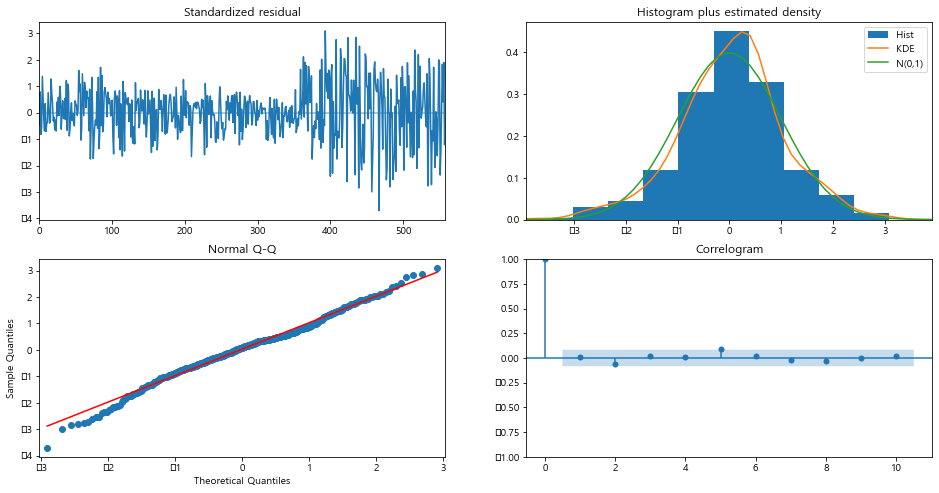

ARIMA 예측 결과:
560    6347.711262
561    7601.205261
562    6891.153233
563    6379.406002
564    5941.936223
dtype: float64


c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\IPython\core\pylabtools.py:137: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


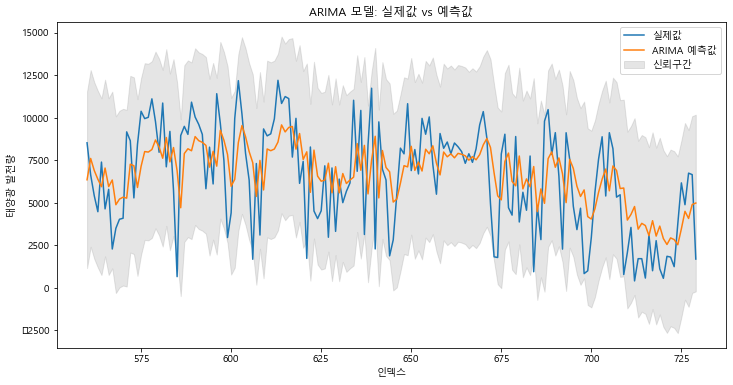

In [42]:
# ARIMA 모델링 프로세스

# 데이터 준비
df_arima = df.copy()
df_arima = df_arima.reset_index(drop=True)
train_data = df_arima['태양광전체'][:split].values
test_data = df_arima['태양광전체'][split:].values

# ADF 테스트 함수
def adf_test(series, signif=0.05):
    result = adfuller(series, autolag='AIC')
    output = {
        'test_statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'n_lags': round(result[2], 4),
        'n_obs': result[3]
    }
    for key, value in result[4].items():
        output[f'critical_value ({key})'] = value
    if result[1] <= signif:
        output['stationary'] = True
    else:
        output['stationary'] = False
    return output

# 태양광 발전량 데이터에 대해 ADF 테스트 수행
adf_result = adf_test(train_data)
print("ADF Test Result:")
print(adf_result)

# 차분 수준 설정
kpss_diffs = pm.arima.ndiffs(train_data, alpha=0.05, test='kpss', max_d=5)
adf_diffs = pm.arima.ndiffs(train_data, alpha=0.05, test='adf', max_d=5)
n_diffs = max(kpss_diffs, adf_diffs)

print(f"Optimal number of differences: {n_diffs}")

# Auto-ARIMA 모델 학습
d_model = pm.auto_arima(train_data, d=n_diffs, seasonal=True, suppress_warnings=True,
                        stepwise=True, n_jobs=-1, start_p=1, start_q=1, max_p=5, max_q=5)

print(d_model.summary())

# ARIMA 모델 진단
d_model.plot_diagnostics(figsize=(16,8))
plt.show()

# 예측 함수 정의
def forecast_one_step(model, new_observation):
    fc, conf_int = model.predict(n_periods=1, return_conf_int=True)
    return fc[0], conf_int[0]

# ARIMA 예측 수행
y_pred_arima = []
pred_upper = []
pred_lower = []

for new_ob in test_data:
    fc, conf = forecast_one_step(d_model, new_ob)
    y_pred_arima.append(fc)
    pred_upper.append(conf[1])
    pred_lower.append(conf[0])
    d_model.update(new_ob)

# 예측값을 Pandas Series로 변환
y_pred_arima_df = pd.Series(y_pred_arima, index=df_arima.index[split:])

# 결과 출력
print("ARIMA 예측 결과:")
print(y_pred_arima_df.head())

# 실제값과 예측값 비교
plt.figure(figsize=(12, 6))
plt.plot(df_arima.index[split:], test_data, label='실제값')
plt.plot(df_arima.index[split:], y_pred_arima, label='ARIMA 예측값')
plt.fill_between(df_arima.index[split:], pred_lower, pred_upper, color='gray', alpha=0.2, label='신뢰구간')
plt.legend()
plt.title('ARIMA 모델: 실제값 vs 예측값')
plt.xlabel('인덱스')
plt.ylabel('태양광 발전량')
plt.show()

In [38]:
# 데이터 크기 확인 및 조정
print("Original sizes:")
print("y_test_seq:", y_test_seq.shape)
print("lstm_pred_seq:", lstm_pred_seq.shape)
print("gru_pred_seq:", gru_pred_seq.shape)
print("rf_pred_scaled:", rf_pred_scaled.shape)
print("xgb_pred_scaled:", xgb_pred_scaled.shape)
print("test_data:", test_data.shape)
print("y_pred_arima_df:", y_pred_arima_df.shape)

# LSTM과 GRU 모델의 예측 결과에 맞춰 다른 모델의 결과 조정
seq_length = y_test_seq.shape[0]
rf_pred_scaled = rf_pred_scaled[-seq_length:]
xgb_pred_scaled = xgb_pred_scaled[-seq_length:]
test_data = test_data[-seq_length:]
y_pred_arima_df = y_pred_arima_df[-seq_length:]

# 예측값 역스케일링
y_test_inv = scaler_y.inverse_transform(y_test_seq)
lstm_pred_inv = scaler_y.inverse_transform(lstm_pred_seq)
gru_pred_inv = scaler_y.inverse_transform(gru_pred_seq)
rf_pred_inv = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1))
xgb_pred_inv = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1))

print("\nAdjusted sizes:")
print("y_test_inv:", y_test_inv.shape)
print("lstm_pred_inv:", lstm_pred_inv.shape)
print("gru_pred_inv:", gru_pred_inv.shape)
print("rf_pred_inv:", rf_pred_inv.shape)
print("xgb_pred_inv:", xgb_pred_inv.shape)
print("test_data:", test_data.shape)
print("y_pred_arima_df:", y_pred_arima_df.shape)

Original sizes:
y_test_seq: (140, 1)
lstm_pred_seq: (140, 1)
gru_pred_seq: (140, 1)
rf_pred_scaled: (170,)
xgb_pred_scaled: (170,)
test_data: (170,)
y_pred_arima_df: (170,)

Adjusted sizes:
y_test_inv: (140, 1)
lstm_pred_inv: (140, 1)
gru_pred_inv: (140, 1)
rf_pred_inv: (140, 1)
xgb_pred_inv: (140, 1)
test_data: (140,)
y_pred_arima_df: (140,)


In [39]:
# 설비 용량의 합 (S)
S = 2400.4

# NMAE 계산 함수
def calculate_nmae(y_true, y_pred, S):
    mask = y_true >= 0.1 * S
    nmae = (np.mean(np.abs(y_true[mask] - y_pred[mask]) / S)) * 100
    return nmae

# 성능 평가 함수
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    nmae = calculate_nmae(y_true, y_pred, S)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, nmae, r2

# 각 모델의 성능 평가
lstm_mse, lstm_mae, lstm_nmae, lstm_r2 = calculate_metrics(y_test_inv, lstm_pred_inv)
gru_mse, gru_mae, gru_nmae, gru_r2 = calculate_metrics(y_test_inv, gru_pred_inv)
rf_mse, rf_mae, rf_nmae, rf_r2 = calculate_metrics(y_test_inv, rf_pred_inv)
xgb_mse, xgb_mae, xgb_nmae, xgb_r2 = calculate_metrics(y_test_inv, xgb_pred_inv)
arima_mse, arima_mae, arima_nmae, arima_r2 = calculate_metrics(test_data, y_pred_arima_df)

# 결과 출력
print("\nModel Performance:")
print("LSTM - MSE:", lstm_mse, "MAE:", lstm_mae, "NMAE:", lstm_nmae, "R2:", lstm_r2)
print("GRU - MSE:", gru_mse, "MAE:", gru_mae, "NMAE:", gru_nmae, "R2:", gru_r2)
print("Random Forest - MSE:", rf_mse, "MAE:", rf_mae, "NMAE:", rf_nmae, "R2:", rf_r2)
print("XGBoost - MSE:", xgb_mse, "MAE:", xgb_mae, "NMAE:", xgb_nmae, "R2:", xgb_r2)
print("ARIMA - MSE:", arima_mse, "MAE:", arima_mae, "NMAE:", arima_nmae, "R2:", arima_r2)


Model Performance:
LSTM - MSE: 9515339.506876836 MAE: 2608.6749521763395 NMAE: 108.67667689453171 R2: 0.012879018773063189
GRU - MSE: 23588018.320172597 MAE: 4098.96130569894 NMAE: 170.76159413843274 R2: -1.4470201796352065
Random Forest - MSE: 3909755.8487867527 MAE: 1526.0909720013603 NMAE: 63.57652774543244 R2: 0.5944020676274447
XGBoost - MSE: 5356240.092234494 MAE: 1827.4742538295202 NMAE: 76.1320718975804 R2: 0.44434384377852043
ARIMA - MSE: 6928493.1450232 MAE: 2136.431812045536 NMAE: 89.00315830884585 R2: 0.2812383681321513


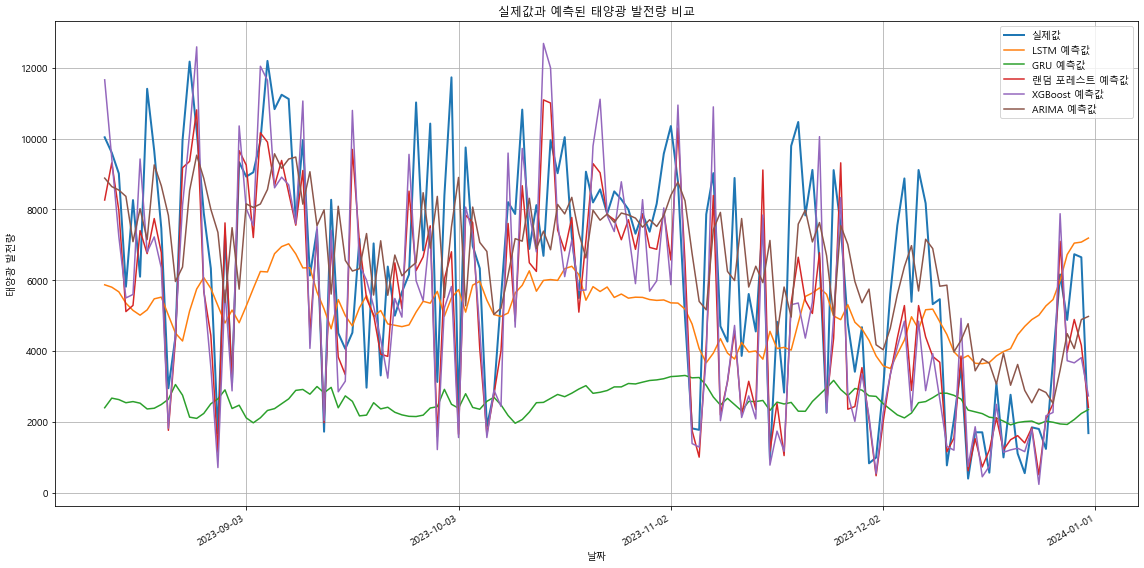

In [43]:
import matplotlib.dates as mdates


# 날짜 인덱스 생성
date_index = df.index[split+time_steps:]

# 실제값과 예측값 시각화
plt.figure(figsize=(16, 8))
plt.plot(date_index, y_test_inv, label='실제값', linewidth=2)
plt.plot(date_index, lstm_pred_inv, label='LSTM 예측값')
plt.plot(date_index, gru_pred_inv, label='GRU 예측값')
plt.plot(date_index, rf_pred_inv, label='랜덤 포레스트 예측값')
plt.plot(date_index, xgb_pred_inv, label='XGBoost 예측값')
plt.plot(date_index, y_pred_arima_df[-len(date_index):], label='ARIMA 예측값')

# x축 날짜 형식 설정
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=30))  # 30일 간격으로 눈금 표시

plt.title('실제값과 예측된 태양광 발전량 비교')
plt.xlabel('날짜')
plt.ylabel('태양광 발전량')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()  # 날짜 레이블 자동 포맷
plt.tight_layout()
plt.show()

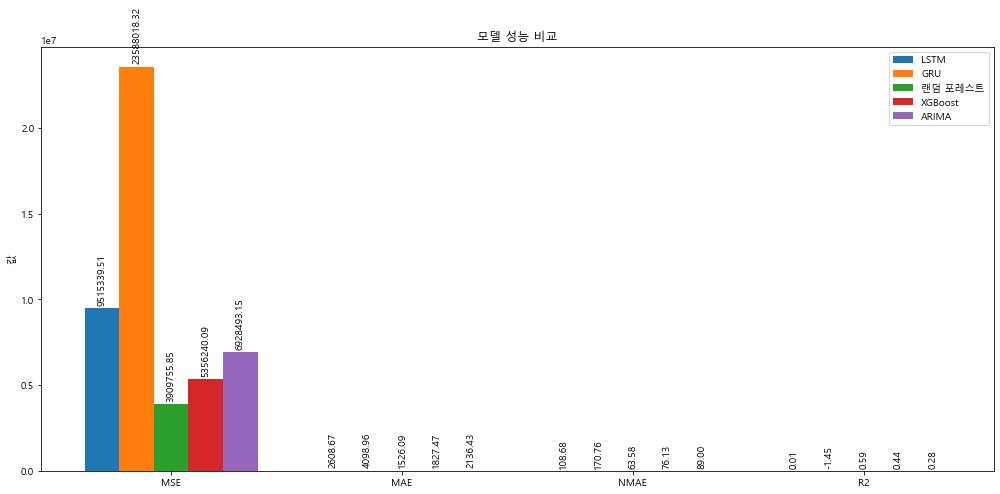

In [44]:
# 성능 평가 비교 시각화
metrics = ['MSE', 'MAE', 'NMAE', 'R2']
lstm_metrics = [lstm_mse, lstm_mae, lstm_nmae, lstm_r2]
gru_metrics = [gru_mse, gru_mae, gru_nmae, gru_r2]
rf_metrics = [rf_mse, rf_mae, rf_nmae, rf_r2]
xgb_metrics = [xgb_mse, xgb_mae, xgb_nmae, xgb_r2]
arima_metrics = [arima_mse, arima_mae, arima_nmae, arima_r2]

x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - 2*width, lstm_metrics, width, label='LSTM')
rects2 = ax.bar(x - width, gru_metrics, width, label='GRU')
rects3 = ax.bar(x, rf_metrics, width, label='랜덤 포레스트')
rects4 = ax.bar(x + width, xgb_metrics, width, label='XGBoost')
rects5 = ax.bar(x + 2*width, arima_metrics, width, label='ARIMA')

ax.set_ylabel('값')
ax.set_title('모델 성능 비교')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 각 막대 위에 값 표시
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)

fig.tight_layout()
plt.show()

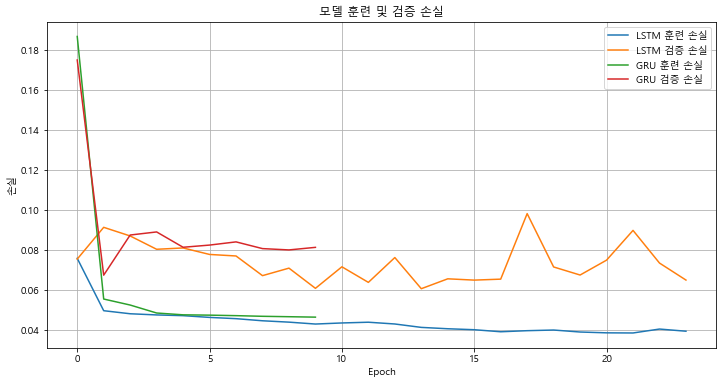

In [45]:
# 손실 그래프 시각화
plt.figure(figsize=(12, 6))
plt.plot(lstm_history.history['loss'], label='LSTM 훈련 손실')
plt.plot(lstm_history.history['val_loss'], label='LSTM 검증 손실')
plt.plot(gru_history.history['loss'], label='GRU 훈련 손실')
plt.plot(gru_history.history['val_loss'], label='GRU 검증 손실')
plt.title('모델 훈련 및 검증 손실')
plt.ylabel('손실')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# 정확도 계산 및 출력
def calculate_accuracy(r2):
    return max(0, min(100, r2 * 100))  # 0-100 사이로 제한

lstm_accuracy = calculate_accuracy(lstm_r2)
gru_accuracy = calculate_accuracy(gru_r2)
rf_accuracy = calculate_accuracy(rf_r2)
xgb_accuracy = calculate_accuracy(xgb_r2)
arima_accuracy = calculate_accuracy(arima_r2)

print("모델 정확도:")
print(f"LSTM 정확도: {lstm_accuracy:.2f}%")
print(f"GRU 정확도: {gru_accuracy:.2f}%")
print(f"랜덤 포레스트 정확도: {rf_accuracy:.2f}%")
print(f"XGBoost 정확도: {xgb_accuracy:.2f}%")
print(f"ARIMA 정확도: {arima_accuracy:.2f}%")

모델 정확도:
LSTM 정확도: 1.29%
GRU 정확도: 0.00%
랜덤 포레스트 정확도: 59.44%
XGBoost 정확도: 44.43%
ARIMA 정확도: 28.12%


In [53]:
# 모델 성능 비교 테이블 생성
performance_data = {
    'Model': ['LSTM', 'GRU', 'Random Forest', 'XGBoost', 'ARIMA'],
    'MSE': [lstm_mse, gru_mse, rf_mse, xgb_mse, arima_mse],
    'MAE': [lstm_mae, gru_mae, rf_mae, xgb_mae, arima_mae],
    'NMAE': [lstm_nmae, gru_nmae, rf_nmae, xgb_nmae, arima_nmae],
    'R2': [lstm_r2, gru_r2, rf_r2, xgb_r2, arima_r2],
    'Accuracy': [lstm_accuracy, gru_accuracy, rf_accuracy, xgb_accuracy, arima_accuracy]
}

performance_df = pd.DataFrame(performance_data)
print("\n모델 성능 비교 테이블:")
print(performance_df.to_string(index=False))




모델 성능 비교 테이블:
        Model          MSE         MAE       NMAE        R2  Accuracy
         LSTM 9.515340e+06 2608.674952 108.676677  0.012879  1.287902
          GRU 2.358802e+07 4098.961306 170.761594 -1.447020  0.000000
Random Forest 3.909756e+06 1526.090972  63.576528  0.594402 59.440207
      XGBoost 5.356240e+06 1827.474254  76.132072  0.444344 44.434384
        ARIMA 6.928493e+06 2136.431812  89.003158  0.281238 28.123837


In [49]:
# 최고 성능 모델 선정
best_model = performance_df.loc[performance_df['R2'].idxmax()]
print(f"\n최고 성능 모델: {best_model['Model']}")
print(f"R2 점수: {best_model['R2']:.4f}")
print(f"정확도: {best_model['Accuracy']:.2f}%")
print(f"MSE: {best_model['MSE']:.4f}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"NMAE: {best_model['NMAE']:.4f}%")


최고 성능 모델: Random Forest
R2 점수: 0.5944
정확도: 59.44%
MSE: 3909755.8488
MAE: 1526.0910
NMAE: 63.5765%


In [51]:
!pip freeze
!pip freeze > requirements.txt

absl-py==2.1.0
argon2-cffi==21.1.0
asgiref==3.6.0
astunparse==1.6.3
attrs==23.2.0
backcall==0.2.0
beautifulsoup4==4.12.3
bitstring==4.0.2
bleach==4.1.0
branca==0.7.1
cachetools==5.3.3
certifi==2024.2.2
cffi==1.15.0
charset-normalizer==3.3.2
colorama==0.4.4
contourpy==1.0.7
cryptography==40.0.2
cycler==0.11.0
Cython==3.0.10
db-dtypes==1.2.0
debugpy==1.5.0
decorator==5.1.0
defusedxml==0.7.1
Django==4.1.5
ecdsa==0.18.0
entrypoints==0.3
esptool==4.5.1
et-xmlfile==1.1.0
exceptiongroup==1.2.0
flatbuffers==24.3.25
folium==0.16.0
fonttools==4.39.4
gast==0.6.0
google-api-core==2.19.0
google-auth==2.29.0
google-auth-oauthlib==1.2.0
google-cloud-bigquery==3.22.0
google-cloud-bigquery-storage==2.25.0
google-cloud-core==2.4.1
google-crc32c==1.5.0
google-pasta==0.2.0
google-resumable-media==2.7.0
googleapis-common-protos==1.63.0
grpcio==1.63.0
grpcio-status==1.62.2
h11==0.14.0
h5py==3.11.0
idna==3.6
importlib-resources==5.12.0
importlib_metadata==8.0.0
ipykernel==6.4.1
ipython==7.28.0
ipython-genuti